In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score

from xgboost import XGBRegressor, plot_importance
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/ML solarcell dataset/concatenated_all_final.xlsx')

df.head(5)

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Nv,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971704,37.583326,87.4922,31.9520,Structure_1
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971972,37.923123,87.5007,32.2529,Structure_1
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972158,38.144859,87.4986,32.4469,Structure_1
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972395,38.294786,87.3901,32.5420,Structure_1
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972767,38.399561,87.0872,32.5304,Structure_1


In [45]:
df

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Nv,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure
0,0.1,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971704,37.583326,87.4922,31.9520,Structure_1
1,0.2,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971972,37.923123,87.5007,32.2529,Structure_1
2,0.3,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972158,38.144859,87.4986,32.4469,Structure_1
3,0.4,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972395,38.294786,87.3901,32.5420,Structure_1
4,0.5,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972767,38.399561,87.0872,32.5304,Structure_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16785,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+18,3000,20,5.000000e+19,100000000000000,1.033562,43.550977,83.3367,37.5121,Structure_24
16786,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+19,3000,20,5.000000e+19,100000000000000,1.004519,43.550975,84.9360,37.1576,Structure_24
16787,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+17,3000,20,5.000000e+19,100000000000000,1.003279,43.550977,84.9916,37.1360,Structure_24
16788,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+18,3000,20,5.000000e+19,100000000000000,0.988246,43.550976,85.6034,36.8429,Structure_24


In [46]:
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['Structure'] = le.fit_transform(df['Structure'])

# Replace 'Structure_x' with just x
df["Structure"] = df["Structure"].str.replace("Structure_", "").astype(int)

In [47]:
bsf_map = {
    1: 'MoS2', 2: 'MoS2', 3: 'WSe2', 4: 'MoS2', 5: 'WSe2', 6: 'MoS2', 7: 'CGS', 8: 'MoS2',
    9: 'WSe2', 10: 'MoS2', 11: 'CGS', 12: 'WSe2', 13: 'MoS2', 14: 'MoS2', 15: 'CGS',
    16: 'WSe2', 17: 'WSe2', 18: 'MoS2', 19: 'CGS', 20: 'WSe2', 21: 'WSe2',
    22: 'WSe2', 23: 'CGS', 24: 'WSe2',
}

# Create new column using map
df["BSF"] = df["Structure"].map(bsf_map)

bsf_map = {
    'MoS2': 1,
    'WSe2': 2,
    'CGS': 3,
}

# Create new column using map
df["BSF"] = df["BSF"].map(bsf_map)

In [48]:
df.describe()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF
count,16790.000000,16790.000000,16790.000000,16790.000000,1.679000e+04,1.679000e+04,16790.000000,16790.000000,1.679000e+04,1.679000e+04,...,16790.000000,16790.000000,1.679000e+04,1.679000e+04,16790.000000,16790.000000,16790.000000,16790.000000,16790.000000,16790.000000
mean,3.007433,1.401331,4.262519,12.645408,5.655086e+18,1.736610e+19,330.229801,110.002824,8.381587e+17,1.033385e+14,...,1018.513401,25.298035,4.319529e+19,1.193201e+14,0.994534,37.207171,82.330058,30.274492,12.357594,1.789756
std,5.261317,0.175999,0.192034,2.773158,1.019237e+19,2.494934e+19,456.961158,171.066425,5.584472e+18,3.850195e+14,...,1202.437309,5.517113,6.022537e+19,3.824673e+14,0.143752,7.213629,6.459050,6.761151,6.842070,0.723895
min,0.100000,0.900000,3.800000,1.000000,5.000000e+15,5.000000e+15,10.000000,1.000000,1.000000e+14,1.000000e+11,...,10.000000,1.000000,1.000000e+15,1.000000e+12,0.476734,0.005364,22.475700,0.005200,1.000000,1.000000
25%,0.700000,1.200000,4.100000,10.500000,1.180000e+18,4.570000e+18,100.000000,25.000000,1.000000e+16,1.000000e+14,...,100.000000,20.000000,1.000000e+18,1.000000e+14,0.911674,34.735479,79.623800,25.892425,6.000000,1.000000
50%,0.700000,1.500000,4.280000,12.500000,1.200000e+18,5.200000e+18,130.000000,50.000000,1.000000e+16,1.000000e+14,...,700.000000,25.000000,5.000000e+19,1.000000e+14,0.999238,38.514235,83.437550,31.571900,12.000000,2.000000
75%,0.800000,1.500000,4.400000,14.800000,2.200000e+18,1.800000e+19,320.000000,56.700000,1.000000e+16,1.000000e+14,...,3000.000000,30.000000,5.000000e+19,1.000000e+14,1.097389,41.675635,86.670900,35.865650,18.000000,2.000000
max,19.000000,2.350000,5.200000,45.000000,1.000000e+20,1.000000e+20,1350.000000,500.000000,5.000000e+19,1.000000e+16,...,3000.000000,90.000000,5.000000e+20,1.000000e+16,1.539987,57.958243,91.135200,43.931400,24.000000,3.000000


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16790 entries, 0 to 16789
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L1 Thickness  16790 non-null  float64
 1   L1 Bg         16790 non-null  float64
 2   L1 Ea         16790 non-null  float64
 3   L1 Dp         16790 non-null  float64
 4   L1 Nc         16790 non-null  float64
 5   L1 Nv         16790 non-null  float64
 6   L1 Ue         16790 non-null  float64
 7   L1 Uh         16790 non-null  float64
 8   L1 Na         16790 non-null  float64
 9   L1 dd         16790 non-null  int64  
 10  L2 Thickness  16790 non-null  float64
 11  L2 Bg         16790 non-null  float64
 12  L2 Ea         16790 non-null  float64
 13  L2 Dp         16790 non-null  float64
 14  L2 Nc         16790 non-null  float64
 15  L2 Nv         16790 non-null  float64
 16  L2 Ue         16790 non-null  int64  
 17  L2 Uh         16790 non-null  int64  
 18  L2 Na         16790 non-nu

In [50]:
for col in df.columns:
  if col not in  ['Structure', 'BSF']:
    df[col] = df[col].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16790 entries, 0 to 16789
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L1 Thickness  16790 non-null  float64
 1   L1 Bg         16790 non-null  float64
 2   L1 Ea         16790 non-null  float64
 3   L1 Dp         16790 non-null  float64
 4   L1 Nc         16790 non-null  float64
 5   L1 Nv         16790 non-null  float64
 6   L1 Ue         16790 non-null  float64
 7   L1 Uh         16790 non-null  float64
 8   L1 Na         16790 non-null  float64
 9   L1 dd         16790 non-null  float64
 10  L2 Thickness  16790 non-null  float64
 11  L2 Bg         16790 non-null  float64
 12  L2 Ea         16790 non-null  float64
 13  L2 Dp         16790 non-null  float64
 14  L2 Nc         16790 non-null  float64
 15  L2 Nv         16790 non-null  float64
 16  L2 Ue         16790 non-null  float64
 17  L2 Uh         16790 non-null  float64
 18  L2 Na         16790 non-nu

In [51]:
# Finding max value
max = df.PCE.max()
max

43.9314

In [52]:
df['FF'] = df['FF'] / 100

In [ ]:
# df[df["FF"] < .50]

In [ ]:
# df = df[df["FF"] >= .50]

In [ ]:
# df = df[df.PCE != 0]

In [27]:
df.head()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.971704,37.583326,0.874922,31.9520,1,1
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.971972,37.923123,0.875007,32.2529,1,1
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.972158,38.144859,0.874986,32.4469,1,1
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.972395,38.294786,0.873901,32.5420,1,1
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.972767,38.399561,0.870872,32.5304,1,1


In [53]:
df.drop(columns=["Structure"], inplace=True)

In [54]:
df['L1 Bg + L1 Ea'] = df['L1 Bg'] + df['L1 Ea']
df['L2 Bg + L2 Ea'] = df['L2 Bg'] + df['L2 Ea']

df['CB offset'] = df['L1 Ea'] - df['L2 Ea']
df['VB offset'] = df['L1 Bg + L1 Ea'] - df['L2 Bg + L2 Ea']

df.drop(columns=["L1 Bg + L1 Ea", "L2 Bg + L2 Ea"], inplace=True)

In [55]:
df.columns

Index(['L1 Thickness', 'L1 Bg', 'L1 Ea', 'L1 Dp', 'L1 Nc', 'L1 Nv', 'L1 Ue',
       'L1 Uh', 'L1 Na', 'L1 dd', 'L2 Thickness', 'L2 Bg', 'L2 Ea', 'L2 Dp',
       'L2 Nc', 'L2 Nv', 'L2 Ue', 'L2 Uh', 'L2 Na', 'L2 dd', 'Voc', 'Jsc',
       'FF', 'PCE', 'BSF', 'CB offset', 'VB offset'],
      dtype='object')

# **Train Test Split**

In [ ]:
# # Define y and X structures
# y_structures = [2, 7, 20]

# # Create X and y datasets
# y_data = df[df["Structure"].isin(y_structures)]
# X_data = df[~df["Structure"].isin(y_structures)]

# # Drop "Structure" column from features
# X = X_data.drop(columns=["Structure"])
# y = y_data.drop(columns=["Structure"])


# X_train = X.drop(columns=["Voc", "Jsc", "FF", "PCE"])
# y_train = X[["Voc", "Jsc", "FF", "PCE"]]

# X_test = y.drop(columns=["Voc", "Jsc", "FF", "PCE"])
# y_test = y[["Voc", "Jsc", "FF", "PCE"]]

# print("X_train shape:", X_train.shape)
# print("X_test shape:", X_test.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)

In [ ]:
# Shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [58]:
# Features and target variables
X = df.drop(['Voc', 'Jsc', 'FF', 'PCE',
             'L1 Ue', 'L1 Uh', 'L2 Ue', 'L2 Uh',
             ], axis = 1)

y = df[['Voc', 'Jsc', 'FF', 'PCE']]

# Split the dataset (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [59]:
y_test

,Voc,Jsc,FF,PCE
2360,1.010405,42.872058,0.870508,37.7088
9249,1.173975,21.752675,0.893822,22.8256
2616,1.010751,27.349819,0.850831,23.5203
3995,1.064034,20.347666,0.814916,17.6434
15397,0.986793,43.695987,0.855870,36.9042
...,...,...,...,...
7854,0.983240,41.340103,0.736084,29.9198
16596,1.005926,43.533500,0.836884,36.6484
14838,0.999514,43.502570,0.860622,37.4211
4373,0.795440,40.808784,0.768878,24.9585


# <font color="lightgreen"> **Random Forest Regressor (RF)**

In [72]:
from sklearn.ensemble import RandomForestRegressor

# Define hyperparameter grid for RF
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5],
    # 'min_samples_leaf': [1, 2, 4]
}

# Initialize and tune model
rf = RandomForestRegressor(random_state=42)
rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

# Best RF model
best_rf = rf_grid_search.best_estimator_
rf_y_pred = best_rf.predict(X_test)

# Convert predictions to DataFrame
rf_y_pred_df = pd.DataFrame(rf_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
rf_mse = mean_squared_error(y_test, rf_y_pred_df, multioutput='raw_values')
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_y_pred_df, multioutput='raw_values')
rf_r2 = r2_score(y_test, rf_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_RF = pd.DataFrame({'MSE': rf_mse, 'RMSE': rf_rmse, 'MAE': rf_mae, 'R2 Score': rf_r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print("Random Forest Metrics:\n", metrics_df_RF)


Random Forest Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.000226  0.015028  0.006512  0.989243
Jsc  0.936446  0.967702  0.306776  0.981505
FF   0.000191  0.013820  0.005644  0.952631
PCE  0.787962  0.887672  0.396122  0.982239


In [73]:
print("Best Parameters RF:", rf_grid_search.best_params_)

Best Parameters RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


# <font color="lightgreen"> **Gradient Boosting Regressor (GBR)**

In [74]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor  # Import MultiOutputRegressor

# Define hyperparameter grid for GBR
gbr_param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 5, 10],
    # 'estimator__min_samples_split': [2, 5, 10],
    # 'estimator__min_samples_leaf': [1, 2, 4]
}

# Initialize and tune model using MultiOutputRegressor
# Wrap GradientBoostingRegressor with MultiOutputRegressor for multi-target regression
gbr = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
gbr_grid_search = GridSearchCV(gbr, gbr_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gbr_grid_search.fit(X_train, y_train)

# Best GBR model
best_gbr = gbr_grid_search.best_estimator_
gbr_y_pred = best_gbr.predict(X_test)

# Convert predictions to DataFrame
gbr_y_pred_df = pd.DataFrame(gbr_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
gbr_mse = mean_squared_error(y_test, gbr_y_pred_df, multioutput='raw_values')
gbr_rmse = np.sqrt(gbr_mse)
gbr_mae = mean_absolute_error(y_test, gbr_y_pred_df, multioutput='raw_values')
gbr_r2 = r2_score(y_test, gbr_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_GBR = pd.DataFrame({'MSE': gbr_mse, 'RMSE': gbr_rmse, 'MAE': gbr_mae, 'R2 Score': gbr_r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print("Gradient Boosting Metrics:\n", metrics_df_GBR)

Gradient Boosting Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.000161  0.012689  0.003709  0.992331
Jsc  0.426086  0.652753  0.265835  0.991585
FF   0.000166  0.012869  0.004798  0.958928
PCE  0.577813  0.760140  0.351173  0.986975


In [75]:
print("Best Parameters GB:", gbr_grid_search.best_params_)

Best Parameters GB: {'estimator__learning_rate': 0.2, 'estimator__max_depth': 10, 'estimator__n_estimators': 200}


# <font color="lightgreen"> **Linear regression**

In [70]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.fit_transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [71]:
# Train the model
lr = LinearRegression()
lr.fit(x_train, y_train_scaled)

# Predictions
lr_y_pred = lr.predict(x_test)

# Convert predictions to DataFrame
lr_y_pred_df = pd.DataFrame(lr_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
lr_mse = mean_squared_error(y_test_scaled, lr_y_pred_df, multioutput='raw_values')
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test_scaled, lr_y_pred_df, multioutput='raw_values')
lr_r2 = r2_score(y_test_scaled, lr_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_lr = pd.DataFrame({'MSE': lr_mse, 'RMSE': lr_rmse, 'MAE': lr_mae, 'R2 Score': lr_r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print(metrics_df_lr)

          MSE      RMSE       MAE  R2 Score
Voc  0.323278  0.568575  0.431816  0.683101
Jsc  0.482344  0.694510  0.459017  0.501002
FF   0.782548  0.884617  0.547108  0.183600
PCE  0.650305  0.806415  0.611797  0.325017


# <font color="lightgreen">**DT regressor**

In [66]:
# Defining hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initializing and tuning model
dt = DecisionTreeRegressor(random_state=42)
dt_grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
dt_grid_search.fit(X_train, y_train)

# Best model
best_dt = dt_grid_search.best_estimator_
dt_y_pred = best_dt.predict(X_test)

# Convert predictions to DataFrame
dt_y_pred_df = pd.DataFrame(dt_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
mse = mean_squared_error(y_test, dt_y_pred_df, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, dt_y_pred_df, multioutput='raw_values')
r2 = r2_score(y_test, dt_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_DT = pd.DataFrame({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print(metrics_df_DT)

          MSE      RMSE       MAE  R2 Score
Voc  0.000350  0.018699  0.007437  0.983345
Jsc  1.624959  1.274739  0.342074  0.967907
FF   0.000301  0.017353  0.006051  0.925320
PCE  1.162845  1.078353  0.429304  0.973788


In [67]:
print("Best Parameters:", dt_grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


# <font color="lightgreen"> **XGB regressor**

## basic xgbregressor

In [31]:
# Initializing XGBoost Regressor
xgb_reg = XGBRegressor(objective='reg:squarederror')

# Training the model
xgb_reg.fit(X_train, y_train)

# Predictions
Xgb_y_pred = xgb_reg.predict(X_test)

# Convert predictions to DataFrame
Xgb_y_pred_df = pd.DataFrame(Xgb_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
mse = mean_squared_error(y_test, Xgb_y_pred_df, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, Xgb_y_pred_df, multioutput='raw_values')
r2 = r2_score(y_test, Xgb_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_xgb = pd.DataFrame({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print(metrics_df_xgb)

          MSE      RMSE       MAE  R2 Score
Voc  0.000541  0.023267  0.014617  0.978742
Jsc  2.928758  1.711362  0.987969  0.939827
FF   0.000906  0.030100  0.015160  0.836026
PCE  3.167762  1.779821  1.054899  0.940089


## With Hyper-parameter tuning

In [60]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 10],
    'subsample': [0.8, 1.0],
    # 'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(XGBRegressor(objective='reg:squarederror'), param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model from GridSearchCV
best_model_XGB = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predictions
y_pred_XGB = best_model_XGB.predict(X_test)

# Convert predictions to DataFrame
y_pred_XGB_df = pd.DataFrame(y_pred_XGB, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
mse = mean_squared_error(y_test, y_pred_XGB_df, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_XGB_df, multioutput='raw_values')
r2 = r2_score(y_test, y_pred_XGB_df, multioutput='raw_values')

# Print metrics
metrics_df_XGB = pd.DataFrame({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print(metrics_df_XGB)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
          MSE      RMSE       MAE  R2 Score
Voc  0.000131  0.011447  0.003856  0.993758
Jsc  0.412499  0.642261  0.270876  0.991853
FF   0.000125  0.011178  0.004833  0.969009
PCE  0.559389  0.747923  0.346060  0.987391


In [61]:
print("Best Parameters XGB:", grid_search.best_params_)

Best Parameters XGB: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}


# <font color="lightgreen">**Comparing Models according to PCE**

In [ ]:
# Create a dictionary to store the PCE metrics for each model
pce_metrics = {
    'Decision Tree': metrics_df_DT.loc["PCE"],
    'Linear Regression': metrics_df_lr.loc["PCE"],
    'Gradient Boosting': metrics_df_GBR.loc["PCE"],
    'Random Forest': metrics_df_RF.loc["PCE"],
    'XGBoost': metrics_df_XGB.loc["PCE"]
}

# Create a DataFrame from the dictionary
comparison_df = pd.DataFrame(pce_metrics).T

comparison_df

,MSE,RMSE,MAE,R2 Score
Decision Tree,3.091335,1.758219,0.648204,0.931531
Linear Regression,0.661179,0.813129,0.616494,0.329698
Gradient Boosting,1.469987,1.212430,0.459243,0.967442
Random Forest,2.034092,1.426216,0.559773,0.954947
XGBoost,1.199371,1.095158,0.456469,0.973435


# <font color="violet">**Traning scores of the best model (XGB)**

In [36]:
# Predictions for the training set
y_train_pred = best_model_XGB.predict(X_train)

# Convert predictions to DataFrame
y_train_pred_df = pd.DataFrame(y_train_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation for the training set
mse_train = mean_squared_error(y_train, y_train_pred_df, multioutput='raw_values')
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred_df, multioutput='raw_values')
r2_train = r2_score(y_train, y_train_pred_df, multioutput='raw_values')

# Print metrics for training and testing
metrics_train_df = pd.DataFrame({'MSE': mse_train, 'RMSE': rmse_train, 'MAE': mae_train, 'R2 Score': r2_train},
                                index=['Voc', 'Jsc', 'FF', 'PCE'])

print("Training Metrics:\n", metrics_train_df)

Training Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.000009  0.003033  0.001900  0.999539
Jsc  0.069671  0.263954  0.137331  0.998671
FF   0.000028  0.005281  0.003159  0.992985
PCE  0.106971  0.327064  0.203085  0.997604


# <font color ='violet'> **Feature importance (XGB)**

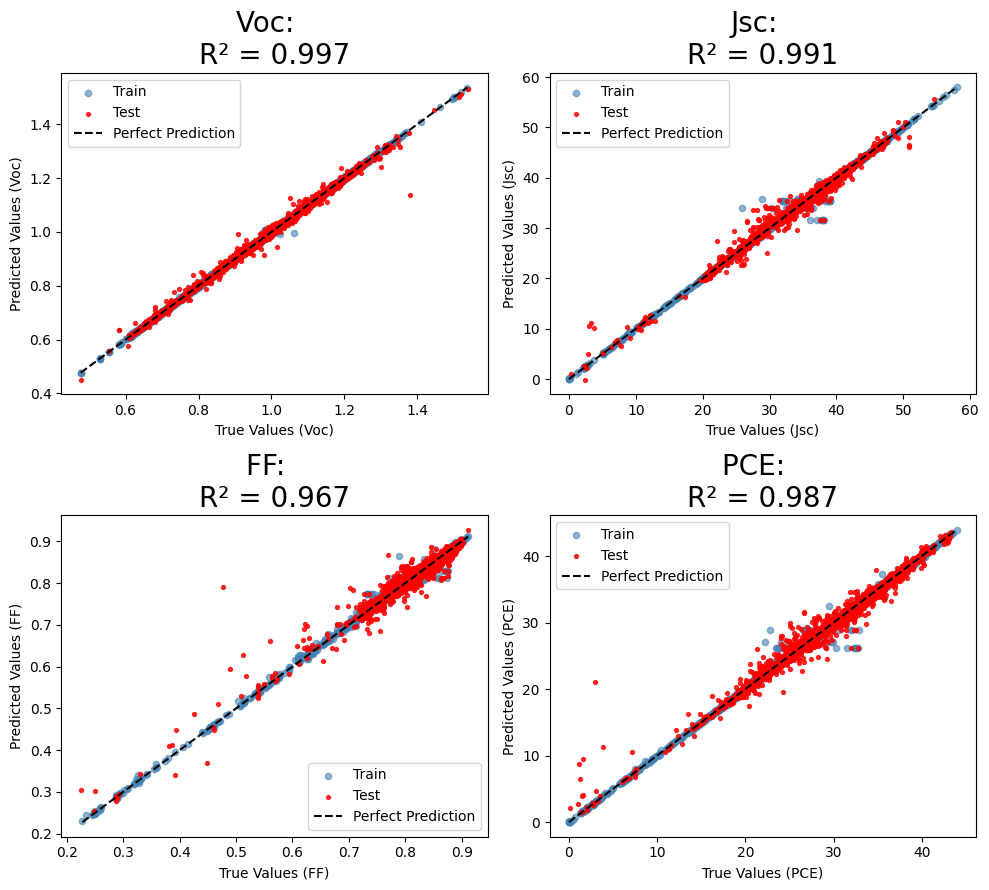

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Define the columns for the plot
columns = ['Voc', 'Jsc', 'FF', 'PCE']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

# Loop through the columns and plot
for i, col in enumerate(columns):
    # Get the subplot position
    ax = axes[i // 2, i % 2]

    # Scatter plot for actual data and predictions
    ax.scatter(y_train[col], y_train_pred_df[col], color='steelblue', label='Train', alpha = 0.6, s= 20)
    ax.scatter(y_test[col], y_pred_XGB_df[col], color='red', label='Test', alpha = 0.8, s= 8)

    # Plot the line of perfect prediction (y = x)
    ax.plot([y_train[col].min(), y_train[col].max()], [y_train[col].min(), y_train[col].max()], 'k--', label='Perfect Prediction')

    # Calculate R² for the test data
    r2_test = r2_score(y_test[col], y_pred_XGB_df[col])

    # Add title, labels, and legend
    ax.set_title(f'{col}:  \nR² = {r2_test:.3f}', size = 20)
    ax.set_xlabel(f'True Values ({col})')
    ax.set_ylabel(f'Predicted Values ({col})')
    ax.legend()

    # Remove grid
    ax.grid(False)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()
